### PyTorch application of a Deep Neural Network (DNN) model for handwritten digit categorization

In [ ]:
"""
PyTorch DNN A\approach for handwritten digit identification

# Project title:
Handwritten digit classification via a Deep Neural Network (DNN) with PyTorch

# Essential tools:
A list of tools and frameworks applied:
Python | Jupyter notebook | google colab | Matplotlib | PyTorch | Torchvision

# Fundamental concepts used:
Supervised machine learning | DNN  | Backpropagation  | Gradient descent optimization | Image Classification | Model Evaluation

# Frameworks and libraries:
Matplotlib | torch | torch.nn | torchvision | torch.optim

# Project Objective:
Main objectives are:
•	Import the MNIST dataset with PyTorch.
•	Clean the data using PyTorch
•	use a DNN for digit classification
•	Convert image data into normalized vectors
•	Train the model with a supervised machine learning on classified images.
•	Use cross entropy loss for minimizing loss
•	Apply the Adam optimizer for better model results
•	Find model accuracy using test data
•	Present a model prediction and true label

"""

In [ ]:
import torch

In [ ]:
import torchvision
from torchvision import transforms

In [ ]:
"""
1. Convert MNIST images (28 x 28) having pixel values (0-255) into a PyTorch tensor of shape [1, 28, 28] normalized pixel values (0 – 1).

2. Normalize the tensor values (0-1) to (-1 to 1) using mean = 0.5 and standard deviation 0.5.

"""
image_transform_normalization = transforms.Compose([transforms.ToTensor(),
                                                    transforms.Normalize((0.5,), (0.5,))
                                                    ])


## Loading the MNIST training dataset

In [ ]:
from torchvision import datasets
# Num. of Training images = 60,000

train_dataset = datasets.MNIST(root='./data', train=True, transform = image_transform_normalization, download=True)
print(train_dataset)

print()

# Initializing the PyTorch DataLoader for Training
# Each batch has 64 images

train_data_loader = torch.utils.data.DataLoader(dataset = train_dataset, batch_size=64, shuffle=True)

print(train_data_loader)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )



In [ ]:
image, labels = train_dataset[3]
image

tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1

In [ ]:
labels

1

## Loading the MNIST Test Data

In [ ]:
# 10,000 test images

test_dataset = datasets.MNIST(root='./data', train=False, transform=image_transform_normalization)
print(test_dataset)

# Generating the Test DataLoader
test_data_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)
print(test_data_loader)

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


In [ ]:
image, labels = test_dataset[5]
image

tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1

In [ ]:
labels

1

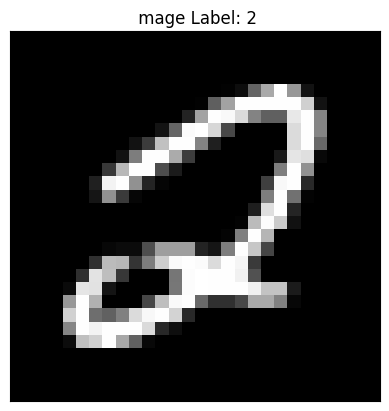

In [ ]:
# visualize mnist sample

import matplotlib.pyplot as plt

def visualize_mnist_sample(data_loader):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    plt.imshow(images[7].numpy().squeeze(), cmap = 'gray')
    plt.xticks([])
    plt.yticks([])
    plt.title(f' mage Label: {labels[7]}')
    plt.show()

visualize_mnist_sample(train_data_loader)

# Creating the MNIST Neural Network using PyTorch

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Define the Neural Network

class MNIST_Digit_Classifier(nn.Module):
  def __init__(self):
    super(MNIST_Digit_Classifier, self).__init__()

    # Building the linear layers of the Neural Network structure
    self.input_layer  = nn.Linear(28*28, 128)
    self.hidden_layer1 = nn.Linear(128, 128)
    self.output_layer = nn.Linear(128, 10)

  # Passing data through the layers
  def forward(self, x):
    x = x.view(-1, 28*28)
    x = F.relu(self.input_layer(x))
    x = F.relu(self.hidden_layer1(x))
    x = self.output_layer(x)
    return x

# Choosing loss and optimizer for training data

In [ ]:
# Set Up Loss Function and Optimizer

import torch.optim as optim

# Model initialization
model = MNIST_Digit_Classifier()

loss_function = nn.CrossEntropyLoss()

training_optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model

In [ ]:
#  Training the Model and Save the model at each epoch

import torch.nn.functional as F

# Define the path for saving the model
mnist_classifier_file_path = './mnist_classifier.pth'

n_training_epochs = 20

for training_epoch in range(n_training_epochs):
  model.train()

  # Initializing Variables
  epoch_loss = 0.0
  correct_train_predictions = 0
  total_training_samples = 0

  for images, labels in train_data_loader:
    training_optimizer .zero_grad()    # Clear gradients from previous step
    model_predictions = model(images)
    training_loss = loss_function(model_predictions, labels)
    training_loss.backward()
    training_optimizer.step()

    epoch_loss += training_loss.item()
    _, train_outputs_predicted = torch.max(model_predictions.data, 1)
    total_training_samples += labels.size(0)
    correct_train_predictions += (train_outputs_predicted == labels).sum().item()

  train_classification_accuracy = 100 *  correct_train_predictions / total_training_samples

  print(f"training epoch {training_epoch+1}/{n_training_epochs }")
  print(f"Loss: {epoch_loss/len(train_data_loader):.4f}")
  print(f"Train Accuracy: {train_classification_accuracy:.2f}%")

  # Save the model
  torch.save(model.state_dict(), mnist_classifier_file_path)
  print(f'Model properly saved at {mnist_classifier_file_path}')

  print()

training epoch 1/20
Loss: 0.3836
Train Accuracy: 88.32%
Model properly saved at ./mnist_classifier.pth

training epoch 2/20
Loss: 0.1750
Train Accuracy: 94.60%
Model properly saved at ./mnist_classifier.pth

training epoch 3/20
Loss: 0.1302
Train Accuracy: 95.96%
Model properly saved at ./mnist_classifier.pth

training epoch 4/20
Loss: 0.1073
Train Accuracy: 96.69%
Model properly saved at ./mnist_classifier.pth

training epoch 5/20
Loss: 0.0902
Train Accuracy: 97.18%
Model properly saved at ./mnist_classifier.pth

training epoch 6/20
Loss: 0.0767
Train Accuracy: 97.58%
Model properly saved at ./mnist_classifier.pth

training epoch 7/20
Loss: 0.0701
Train Accuracy: 97.70%
Model properly saved at ./mnist_classifier.pth

training epoch 8/20
Loss: 0.0613
Train Accuracy: 98.02%
Model properly saved at ./mnist_classifier.pth

training epoch 9/20
Loss: 0.0562
Train Accuracy: 98.17%
Model properly saved at ./mnist_classifier.pth

training epoch 10/20
Loss: 0.0517
Train Accuracy: 98.31%
Model p

# Testing the trained model accuracy

In [ ]:
model.eval()
accurate_predictions = 0
total_predictions = 0
with torch.no_grad():
    for images, labels in test_data_loader:
        model_outputs = model(images)
        _, predicted_labels = torch.max(model_outputs.data, 1)
        total_predictions += labels.size(0)
        accurate_predictions += (predicted_labels == labels).sum().item()

classification_accuracy = (accurate_predictions)*100 / total_predictions
print(f'Test accuracy of MNIST dataset: {classification_accuracy}%')

Test accuracy of MNIST dataset: 97.07%


# Comparing predicted and true labels

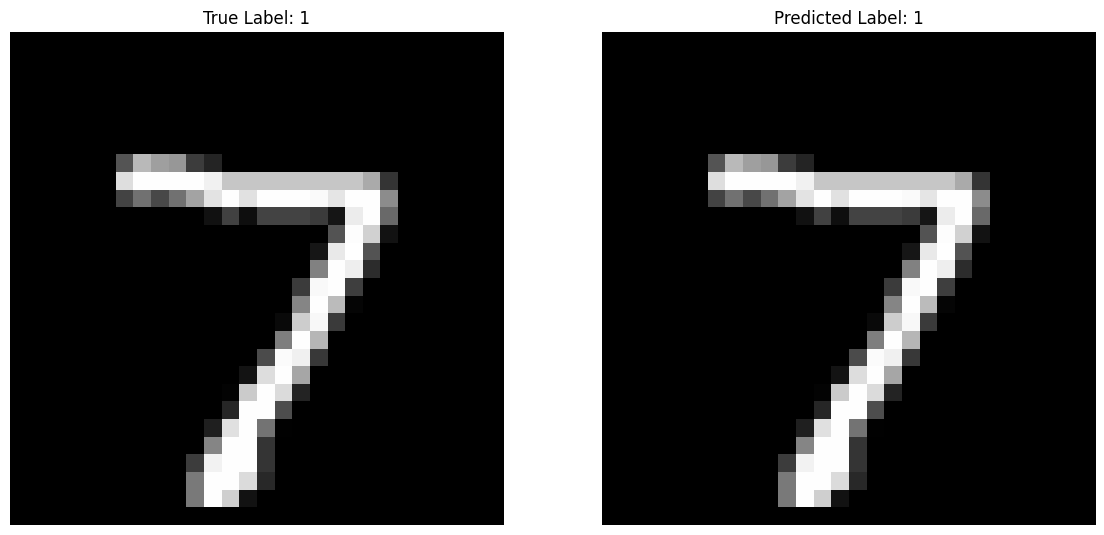

In [ ]:
def show_model_prediction(loader):
  # Put model in evaluation mode
    model.eval()

    data_iterator = iter(loader)

    batch_images, batch_labels = next(data_iterator)

    model_outputs = model(batch_images[2:3])
    _, predicted_labels = torch.max(model_outputs, 1)

    # Plot True image and predicted image
    fig, ax = plt.subplots(1, 2, figsize=(14, 8))
    ax[0].imshow(batch_images[0].numpy().squeeze(), cmap = 'gray')
    ax[0].set_title(f'True Label: {batch_labels[2]}')
    ax[0].axis('off')

    ax[1].imshow(batch_images[0].numpy().squeeze(), cmap = 'gray')
    ax[1].set_title(f'Predicted Label: {predicted_labels.item()}')
    ax[1].axis('off')

    plt.show()


show_model_prediction(test_data_loader)
